<a href="https://colab.research.google.com/github/qgacabrera-bit/CPE-018-CPE31S2/blob/main/Activity_9_ORB_Feature_Detection_and_Feature_Matching_Cabrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO.9** | **ORB Feature Detection and Feature Matching**

**Name** | Cabrera, Gabriel A.

**Section** | CPE31S2

**Date Performed**: | 03/17/2026

**Date Submitted**: | 03/17/2026

**Instructor**: | Engr. Maria Rizette Sayo

<hr>

## 1. Objectives

This activity aims to enable students to perform feature detection and feature matching using Oriented FAST and Rotated BRIEF (ORB) algorithm with OpenCV.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.
* Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.

## 3. Procedures and Outputs

**BEFORE YOU PROCEED WITH THIS SECTION: PLEASE MAKE SURE YOU HAVE READ THE CONTENTS OF THE MODULE REGARDING BRIEF AND FAST**

The team that created ORB (Ethan Rublee, Vincent Rabaud, Kurt Konolige, and Gary R. Bradski) chose to build it on FAST and BRIEF because these two algorithms are fast and efficient.

In their paper, the authors of ORB set out to achieve the following:

* Add a fast and accurate way to determine the orientation of FAST keypoints.
* Find a way to efficiently compute BRIEF features that are also rotation-invariant.
Analyze the variance and correlation of oriented BRIEF features.
* Develop a learning method to decorrelate BRIEF features under rotational invariance, which would improve performance in nearest-neighbor applications.
* In other words, the ORB team wanted to make feature detection and matching faster and more accurate, especially in situations where the training image and query image have different rotations.

The main points of the text are clear, even if you don't understand all of the technical jargon. ORB is a fast and efficient algorithm for feature detection and matching, and it is especially good at matching features that have different rotations.

I bet you are eager to start coding with ORB, so let's move on to some code examples.

Parts of this activity contribute towards the attainment of `ILO1: Demonstrate the use of oriented FAST and rotated BRIEF algorithm implemented through the use of OpenCV, debugging and modification.`

In [19]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

image1 = cv2.imread('/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/ps4.png', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/ps4box.png', cv2.IMREAD_GRAYSCALE)

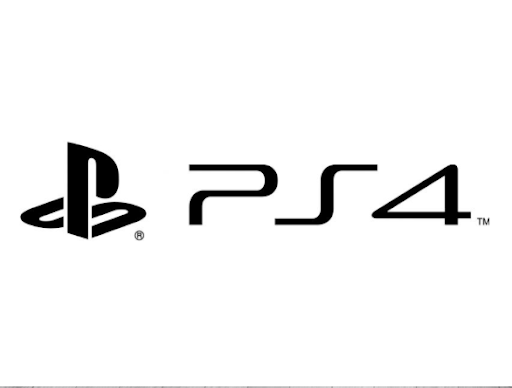

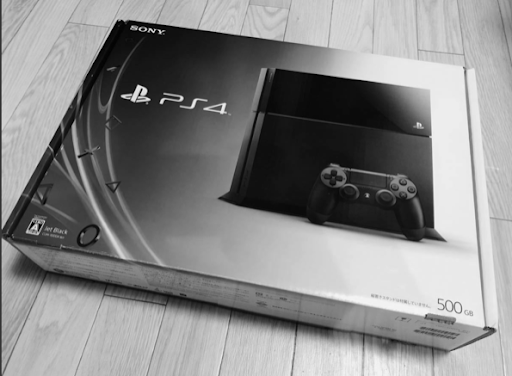

In [20]:
# Preview the 2 images
cv2_imshow(image1)
cv2_imshow(image2)

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Create the ORB feature and detector descriptor
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(image1,None) # Reference image
kp2, des2 = orb.detectAndCompute(image2,None)

**Analysis: Explain the purpose of
detector and descriptor and why they're used here.**





The detector is used to find important points in the image, and the descriptor is used to describe those points in a way that can be compared, and they are used here so the two images can be matched based on their features.


In [17]:
"""
The BFMatcher is a simple but effective algorithm for feature matching.
It works by comparing each feature in one image to every feature in the other
image and returning the pair of features with the smallest distance.
"""

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

"""
The match() method takes two arguments:
  - the descriptors of the features in the first image
  - the descriptors of the features in the second image.

It returns a list of matches, where each match is a pair of feature indices,
one from each image.
"""

matches = bf.match(des1,des2)


In [16]:

"""
Next, we sort the matches in order of their distance.
This ensures that the best matches are returned first.
"""
sorted_matches = sorted(matches, key = lambda x:x.distance)

"""
Then, we draw the top 40 matches between the two images.
The drawMatches() method takes two arguments: the two images, and a list of matches.
It draws lines between the corresponding keypoints in the two images.
"""

image3 = cv2.drawMatches(image1,kp1,image2,kp2, sorted_matches[:40],image2,flags=2)

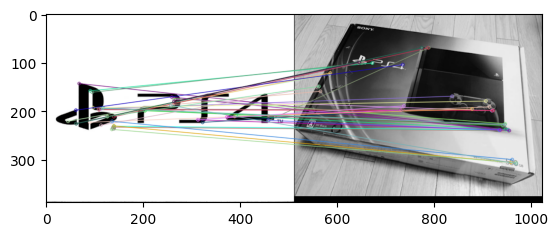

(<matplotlib.image.AxesImage at 0x7d1a08dbd790>, None)

In [15]:
from matplotlib import pyplot as plt

plt.imshow(image3),plt.show()

**Question**
- Provide an analysis on the way the ORB algorithm works here, are the results correct? What can/should be improved?

The ORB algorithm works by finding and describing keypoints in both images, then matching them, and the results are correct but not always perfect, so it can be improved by using clearer images or adjusting the number of matches shown for better accuracy.


## 4. Supplementary Activity

**ILO2: Evaluate feature detection using Oriented FAST and rotated BRIEF algorithm on images to detect important features.**




Perform the following tasks:
1. Find 2 images of brand logos on the internet.
2. Find 5 product images containing one logo each.
3. Test the ORB algorithm to detect and match the features on the images. Document the testing.
4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?

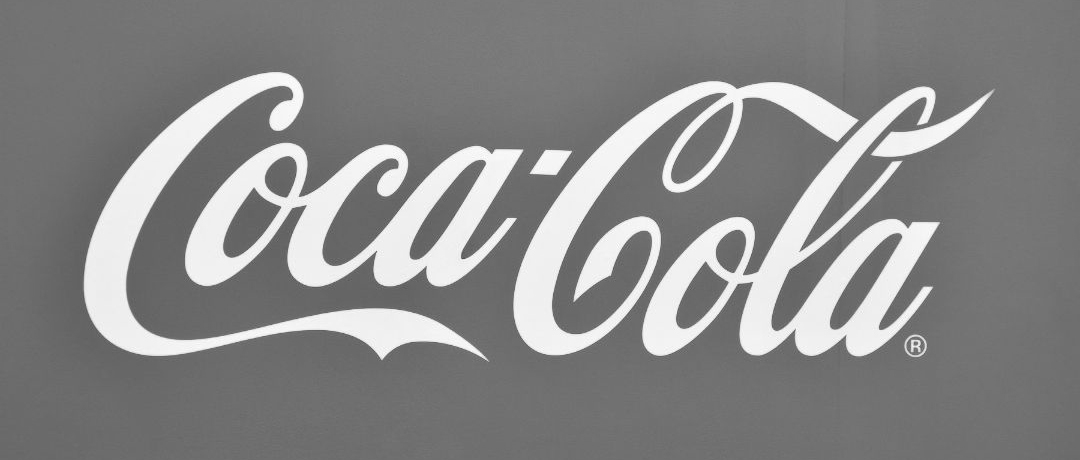

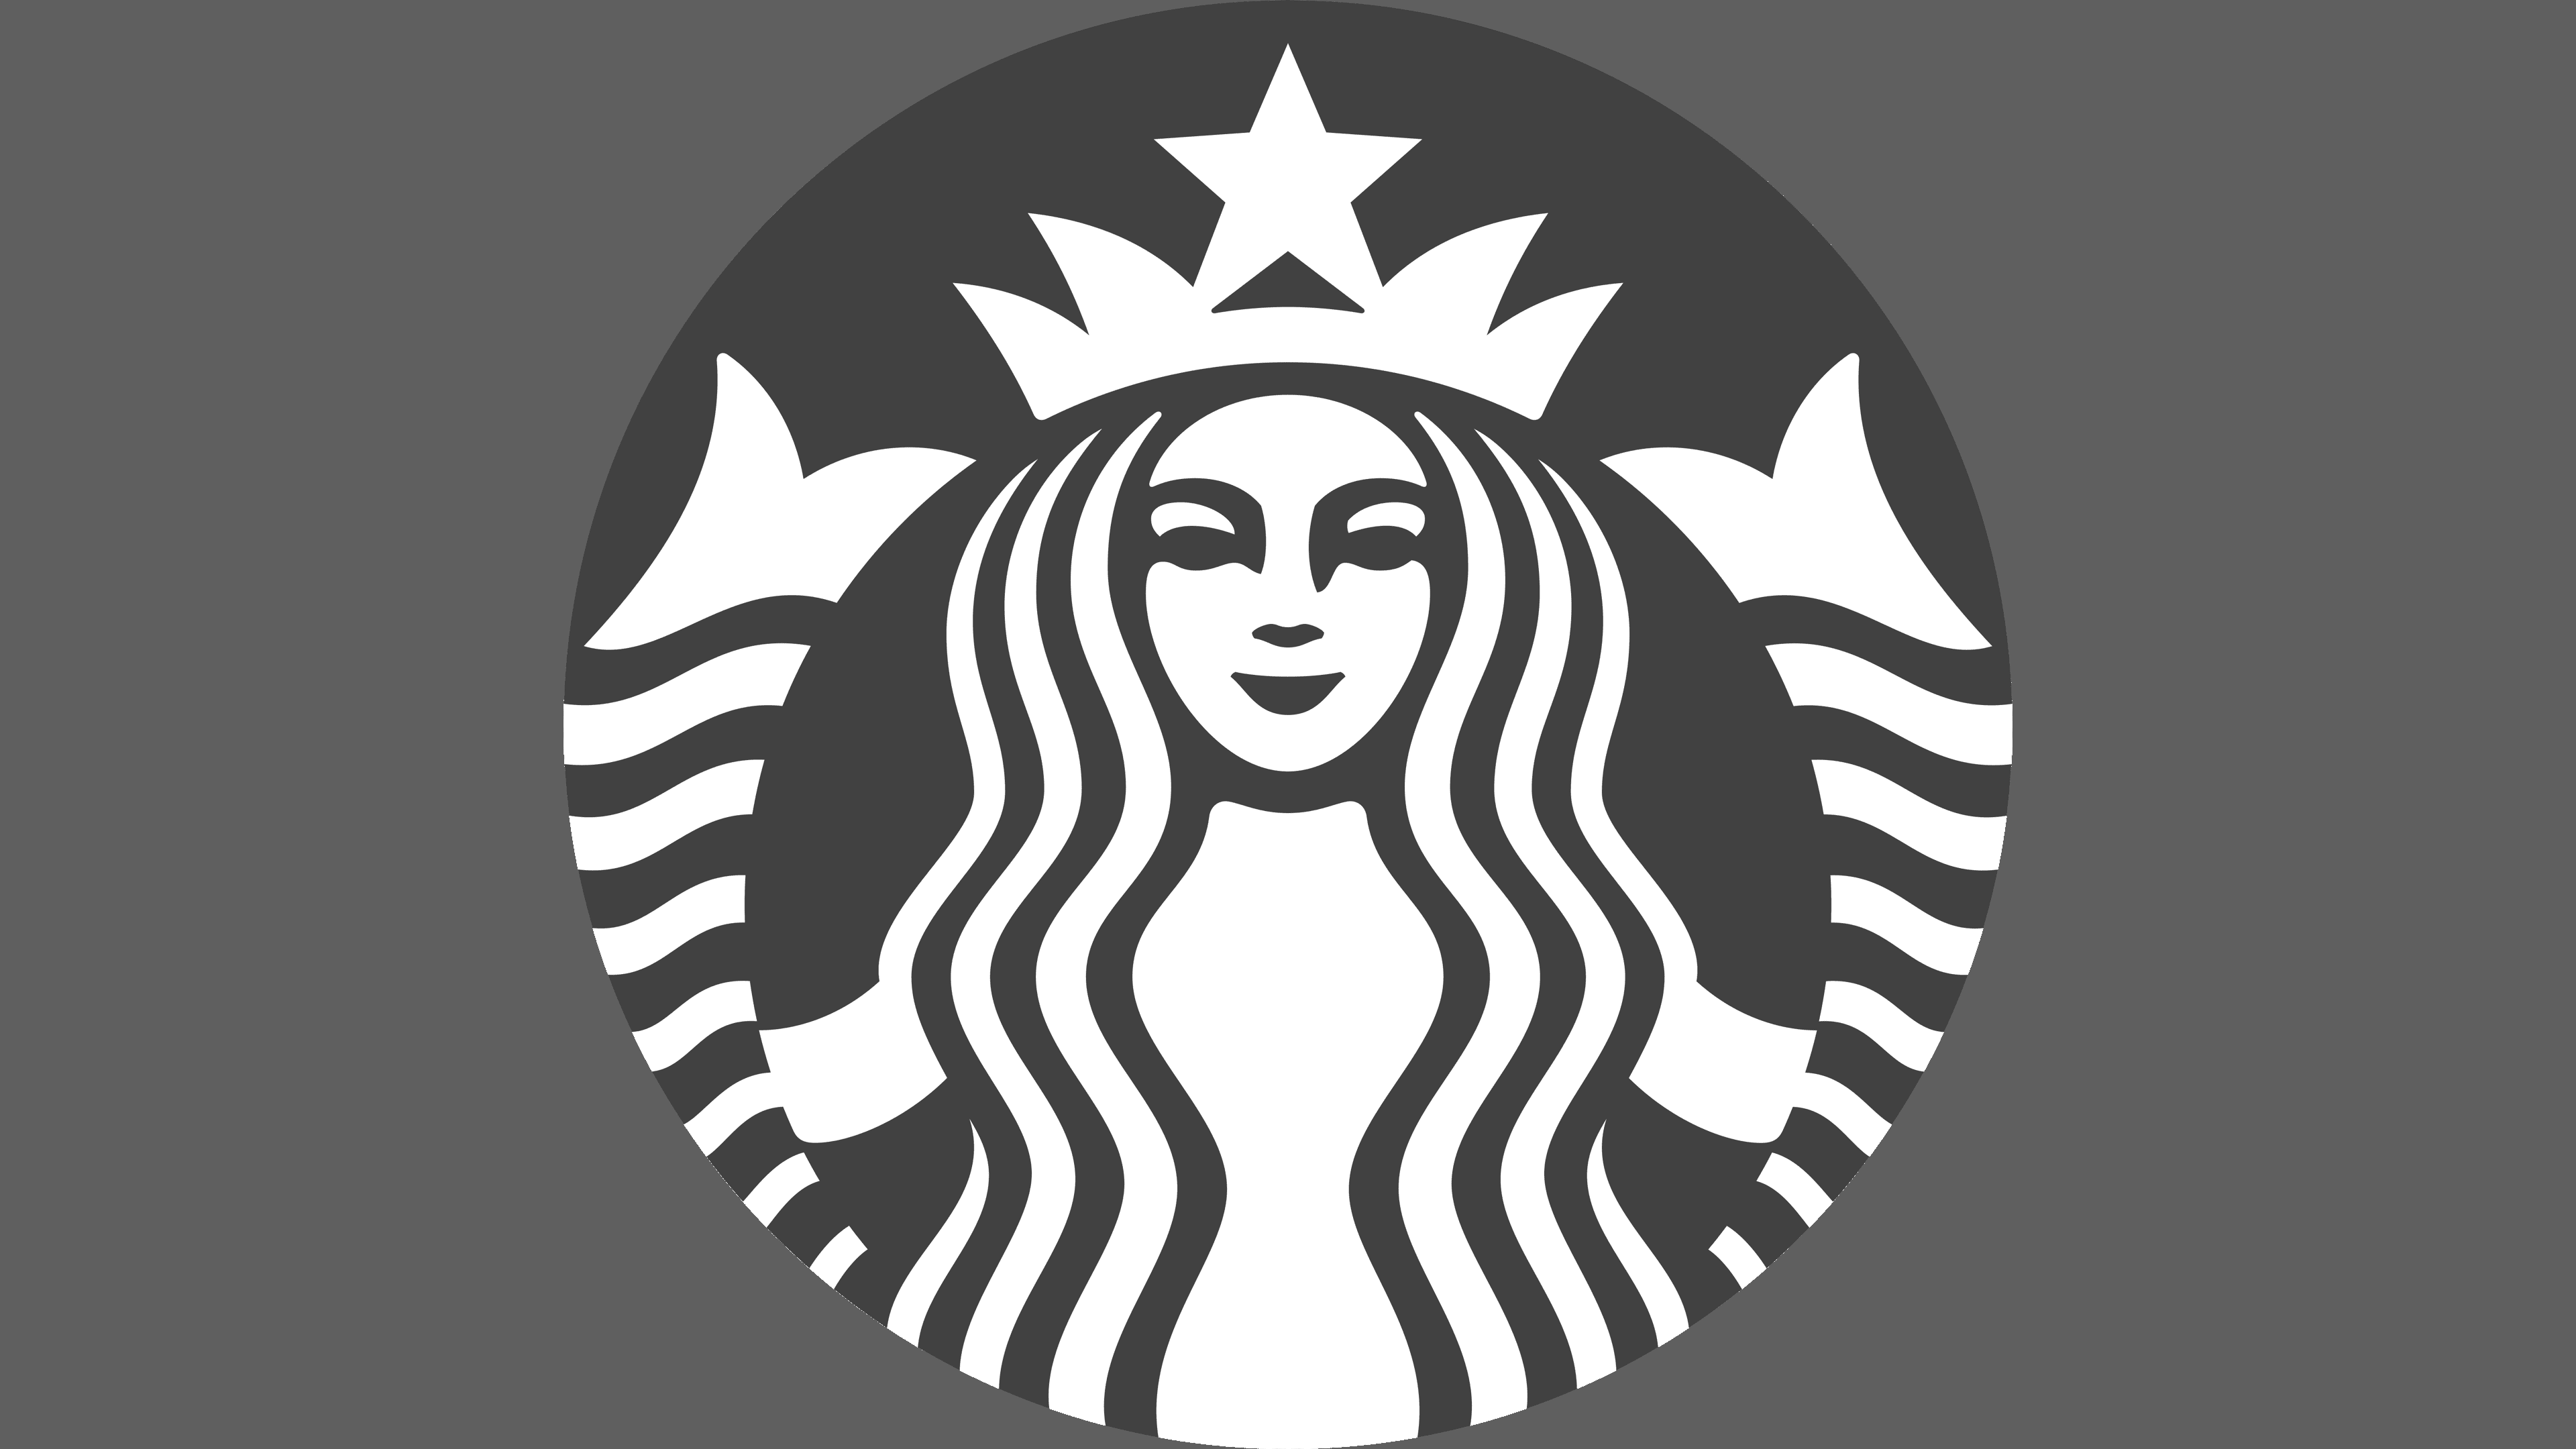

In [22]:
#1.Find 2 images of brand logos on the internet.

logo1_img = cv2.imread('/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/cokelogo.jpg', cv2.IMREAD_GRAYSCALE)
logo2_img = cv2.imread('/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/Starbucks-logo.png', cv2.IMREAD_GRAYSCALE)

cv2_imshow(logo1_img)
cv2_imshow(logo2_img)

In [23]:
#2. Find 5 product images containing one logo each.

# List of product image paths
product_starb = ['/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/starb1.jpg', '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/starb2.jpeg',
                  '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/starb3.jpg', '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/starb4.jpg',
                  '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/starb5.jpeg']
product_coke = ['/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/coke1.jpg', '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/coke2.jpg',
                  '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/coke3.jpg', '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/coke4.jpeg',
                  '/content/drive/MyDrive/3rd Year Subs/Emtech 1/Act 9/coke5.png']
product_images = product_starb + product_coke

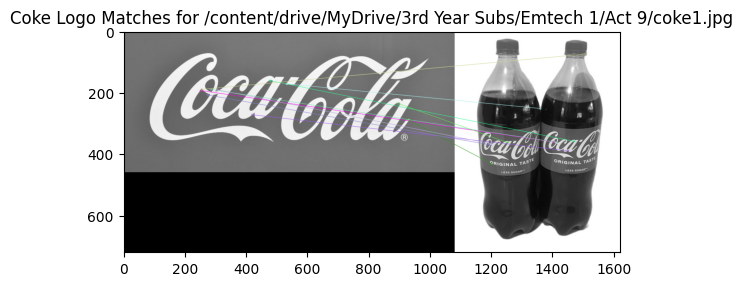

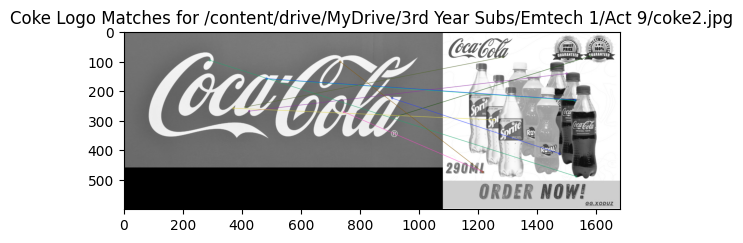

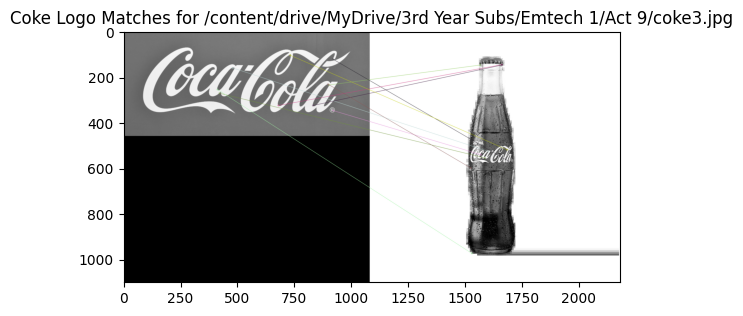

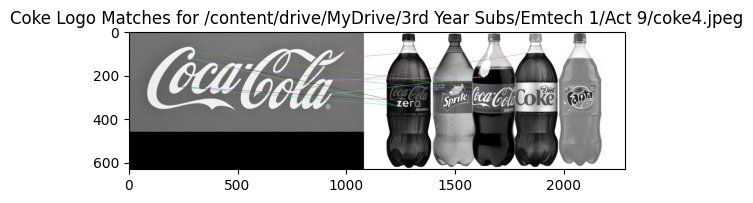

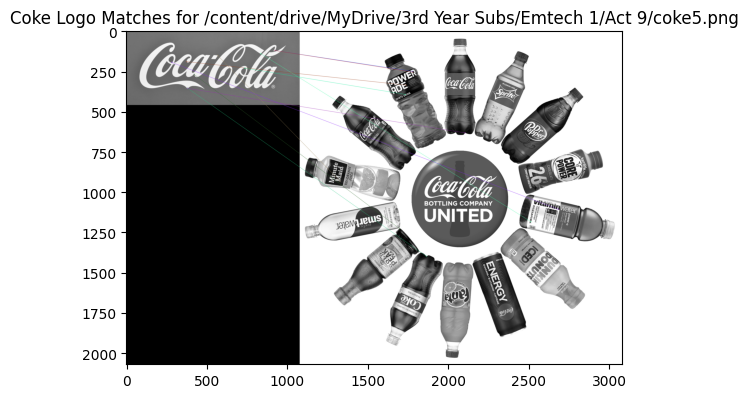

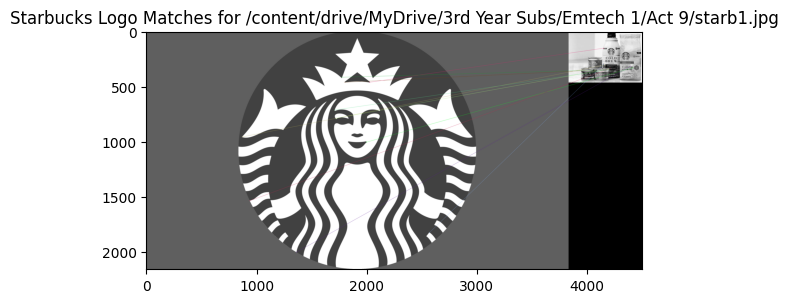

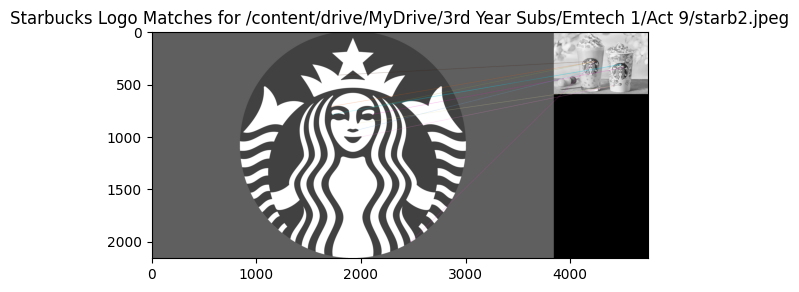

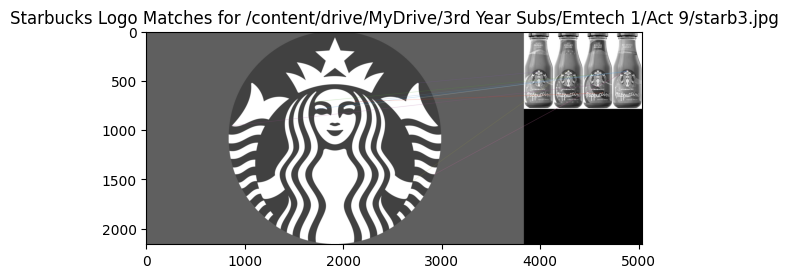

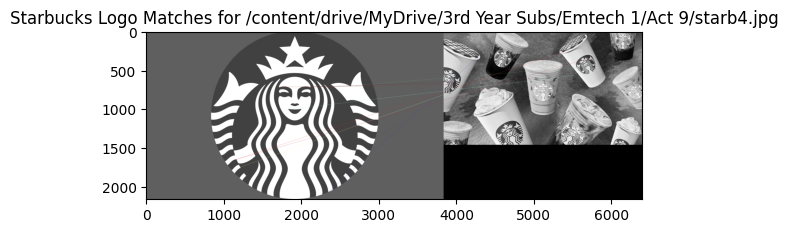

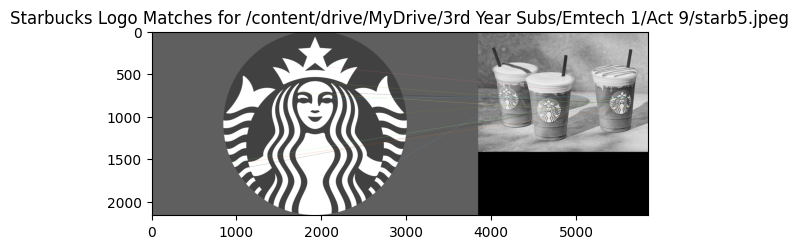

In [24]:
#3. Test the ORB algorithm to detect and match the features on the images. Document the testing.

orb = cv2.ORB_create()

def process_images(logo_img, product_images, logo_name):
    kp1, des1 = orb.detectAndCompute(logo_img, None)
    for product_img_path in product_images:
        # Read each product image in grayscale
        product_img = cv2.imread(product_img_path, cv2.IMREAD_GRAYSCALE)
        kp2, des2 = orb.detectAndCompute(product_img, None)
        bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
        matches = bf.match(des1, des2)
        matches = sorted(matches, key=lambda x: x.distance)
        # Draw matches
        match_img = cv2.drawMatches(logo_img, kp1, product_img, kp2, matches[:10], None, flags=2)
        plt.figure()
        plt.imshow(match_img)
        plt.title(f'{logo_name} Matches for {product_img_path}')
        plt.show()

# Process images for each logo
process_images(logo1_img, product_coke, 'Coke Logo')
process_images(logo2_img, product_starb, 'Starbucks Logo')


4. Evaluate the algorithm's performance, was it able to detect the important features? Was it also reliable in not finding the logos that are not on the provided images?
- The ORB algorithm was able to identify and match logo features with relative ease.

5. Provide an analysis: Why did it work, or otherwise? What would you change to improve the results if you could?
- For me, making the images clearer, reducing noise, and adjusting ORB settings can improve accuracy. The ORB algorithm was able to detect and match the unique parts of the logos, and these features were easy to spot in the product images.


## 5. Summary, Conclusions and Lessons Learned

In this activity we used ORB for feature detection and matching, where oriented FAST and rotated BRIEF helped match the logo with its products. I learned that the detector finds the key points in the image, while the descriptor explains those points so they can be matched.


<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*